# RUG on credit data (binary)

In [847]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [848]:
import pandas as pd 
import numpy as np

from ruleopt import RUGClassifier
from ruleopt.rule_cost import Gini
from ruleopt.solver import ORToolsSolver

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt


In [849]:
# Load features and labels
X_train = pd.read_csv('/Users/apple/Downloads/credit/encoded_credit_X_train.csv')
y_train = pd.read_csv('/Users/apple/Downloads/credit/credit_y_train.csv').squeeze()  # Convert to Series

X_test = pd.read_csv('/Users/apple/Downloads/credit/encoded_credit_X_test.csv')
y_test = pd.read_csv('/Users/apple/Downloads/credit/credit_y_test.csv').squeeze()

In [850]:
df = pd.read_csv("/Users/apple/Downloads/credit/credit_X_train.csv")
print(df.dtypes)
print(df.head())

checking_status           int64
duration                  int64
credit_history            int64
purpose                   int64
credit_amount             int64
savings_status            int64
employment                int64
installment_commitment    int64
personal_status           int64
other_parties             int64
residence_since           int64
property_magnitude        int64
age                       int64
other_payment_plans       int64
housing                   int64
existing_credits          int64
job                       int64
num_dependents            int64
own_telephone             int64
foreign_worker            int64
dtype: object
   checking_status  duration  credit_history  purpose  credit_amount  \
0                0        24               3        4           1246   
1                1        12               3        4            900   
2                3         6               3        4            672   
3                3        10               3        9     

In [851]:
# check the features of the data 

X_test

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_1,checking_status_2,checking_status_3,...,purpose_4,purpose_5,purpose_6,purpose_7,purpose_8,purpose_9,savings_status_1,savings_status_2,savings_status_3,savings_status_4
0,30,2333,4,2,30,1,1,0,0,1,...,0,0,1,0,0,0,1,0,0,0
1,12,1330,4,1,26,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
2,42,6289,2,1,33,2,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,30,3832,2,1,22,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,24,1371,4,4,25,1,1,1,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,18,2864,2,1,34,1,2,0,1,0,...,0,0,0,0,0,0,0,1,0,0
196,24,3777,4,4,50,1,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
197,18,2427,4,2,42,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
198,15,4657,3,2,30,1,1,0,0,1,...,0,0,0,0,0,1,0,1,0,0


# Grid search for max_depth hyperparameter

/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

max_depth=2 → CV accuracy: 0.6863


/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

max_depth=3 → CV accuracy: 0.6713


/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

...

/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

max_depth=5 → CV accuracy: 0.6950


/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

max_depth=6 → CV accuracy: 0.6763

Best max_depth = 5 with CV accuracy = 0.6950


/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


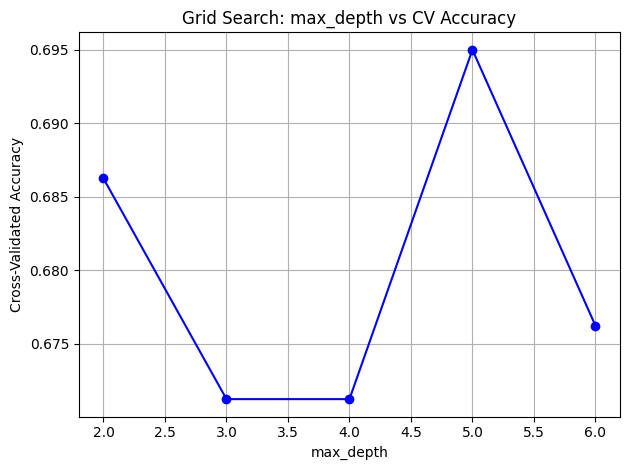

In [852]:
#import necessary libraries
from sklearn.model_selection import cross_val_score


# Depth values to evaluate
depth_values = [2, 3, 4, 5, 6]
cv_scores = []

# Loop over depths
for depth in depth_values:
    rug = RUGClassifier(
        solver=ORToolsSolver(),
        rule_cost=Gini(),
        random_state=42,
        max_rmp_calls=20,
        max_depth=depth,                      # passed directly
        class_weight="balanced"               # also passed directly
    )
    
    # Perform 5-fold CV on training set
    scores = cross_val_score(rug, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    cv_scores.append(mean_score)
    
    print(f"max_depth={depth} → CV accuracy: {mean_score:.4f}")

# Find best depth
best_depth = depth_values[np.argmax(cv_scores)]
print(f"\nBest max_depth = {best_depth} with CV accuracy = {max(cv_scores):.4f}")

# Plot results
plt.plot(depth_values, cv_scores, marker='o', color='blue')
plt.xlabel("max_depth")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Grid Search: max_depth vs CV Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


To select the optimal configuration for RUG, we perform a
grid search over the max depth parameter. The accuracy for several max depth
is shown in the above Figure. The highest cross-validated accuracy (0.695) was observed
at max depth = 5, and was thus selected to train the final model.
Although max depth=2 provides better interpretability while still obtaining
reasonable accuracy (0.686), in very large-scale financial applications even a
0.5 − 1% difference in accuracy can result in significant financial consequences.
Additionally, prior study (Lakkaraju et al., 2016) has shown that for classifica-
tion tasks, rules with 3−5 conditions are typically considered as interpretable by
most humans, especially when the rule-based method has its unique IF–THEN
structure.
Therefore, to balance accuracy and interpretability, the max depth=5 was
chosen to train the final model. The final evaluation metrics were computed in
the held-out test set for each max depth, as shown in the following.

In [853]:
rug = RUGClassifier(
    solver=ORToolsSolver(),
    rule_cost=Gini(),
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)
rug.fit(X_train, y_train)
y_pred_proba = rug.predict_proba(X_test)[:, 1]


y_pred_proba= rug.predict_proba(X_test)[:,1] # Probability of class 1 (default/ bad)


print("ROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba))

/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ROC AUC Score:
0.7473809523809525


/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


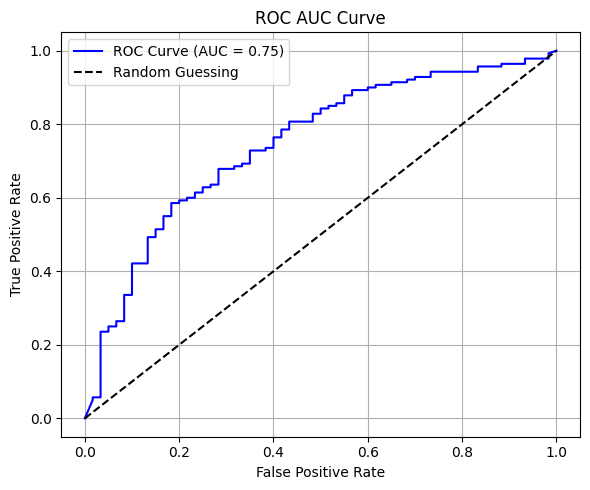

In [854]:
# Compute FPR (False Positive Rate), TPR (True Positive Rate), thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The ROC AUC curve illustrates the trade-off between true positive rate and false positive rate across decision thresholds. The AUC score of 0.73 indicates that the model achieves reasonably strong discriminative performance. It performs substantially better than random guessing, though there remains headroom for improvement (e.g., via feature engineering or ensembling).

In [855]:
# Store results
results = []

for depth in range(2, 7):
    rug = RUGClassifier(
        solver=ORToolsSolver(),
        rule_cost=Gini(),
        max_depth=depth,
        random_state=42,
        class_weight="balanced"
    )
    rug.fit(X_train, y_train)
    y_pred = rug.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "max_depth": depth,
        "precision": round(report["macro avg"]["precision"], 2),
        "recall": round(report["macro avg"]["recall"], 2),
        "f1_score": round(report["macro avg"]["f1-score"], 2),
        "accuracy": round(accuracy, 2)
    })

# Create and show the results table
results_df = pd.DataFrame(results)
print(results_df)

/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: '

   max_depth  precision  recall  f1_score  accuracy
0          2       0.62    0.64      0.63      0.66
1          3       0.68    0.69      0.68      0.72
2          4       0.67    0.68      0.67      0.71
3          5       0.65    0.67      0.66      0.69
4          6       0.63    0.63      0.63      0.69


/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


# Summary

We conducted a grid search using 5-fold cross-validation on the training data to tune the max_depth parameter of the RUG classifier. The highest mean cross-validated accuracy (~0.695) was observed at max_depth = 5, making it the optimal choice based on training-time validation performance.

To assess generalization, we evaluated the trained models on the held-out test set. As shown, max depth = 3 yields the best overall
performance, with the highest accuracy (0.72), precision(0.68), recall(0.69), and F1-score(0.68). max depth=4 is the second best, obtaining comparable performance with each metric being 1% lower than that for max depth=5. In comparison, max depth=2 performed the worst across all metrics. Lastly, max depth of5 and 6 showed moderate results, though max depth=5 slightly outperformed depth 6 in both precision (0.65 vs. 0.63) and recall(0.67 vs. 0.63).

In [856]:
# Final model based on cross-validation: max_depth = 5
rug_final = RUGClassifier(
    solver=ORToolsSolver(),
    rule_cost=Gini(),
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)
rug_final.fit(X_train, y_train)

# Predict on test set
y_pred_final = rug_final.predict(X_test)
y_pred_proba_final = rug_final.predict_proba(X_test)[:, 1]

# Evaluate
print("Final Model Classification Report (depth=5):")
print(classification_report(y_test, y_pred_final))
print("ROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba_final))


/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Final Model Classification Report (depth=5):
              precision    recall  f1-score   support

           0       0.49      0.60      0.54        60
           1       0.81      0.74      0.77       140

    accuracy                           0.69       200
   macro avg       0.65      0.67      0.66       200
weighted avg       0.72      0.69      0.70       200

ROC AUC Score:
0.7473809523809525


In [857]:
y_pred

array([0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0])

In [858]:
X_test.head()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_1,checking_status_2,checking_status_3,...,purpose_4,purpose_5,purpose_6,purpose_7,purpose_8,purpose_9,savings_status_1,savings_status_2,savings_status_3,savings_status_4
0,30,2333,4,2,30,1,1,0,0,1,...,0,0,1,0,0,0,1,0,0,0
1,12,1330,4,1,26,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
2,42,6289,2,1,33,2,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,30,3832,2,1,22,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,24,1371,4,4,25,1,1,1,0,0,...,1,0,0,0,0,0,0,0,0,1


In [859]:
X_test.iloc[0]
# Example prediction for the first individual in the test set.


duration                    30
credit_amount             2333
installment_commitment       4
residence_since              2
age                         30
existing_credits             1
num_dependents               1
checking_status_1            0
checking_status_2            0
checking_status_3            1
credit_history_1             0
credit_history_2             0
credit_history_3             1
credit_history_4             0
employment_1                 0
employment_2                 0
employment_3                 1
employment_4                 0
foreign_worker_1             1
housing_1                    1
housing_2                    0
job_1                        0
job_2                        0
job_3                        0
other_parties_1              0
other_parties_2              1
other_payment_plans_1        0
other_payment_plans_2        0
own_telephone_1              0
personal_status_1            0
personal_status_2            0
personal_status_3            1
property

In [860]:
rug_final

RUGClassifier(class_weight='balanced', max_depth=5, random_state=42,
              rule_cost=<ruleopt.rule_cost.rule_cost.Gini object at 0x12d560f90>,
              solver=<ruleopt.solver.ortools_solver.ORToolsSolver object at 0x12d1dea10>)

# Now we retrieve the rules 

In [861]:
# Initialize the Explainer with the fitted RUGClassifier
from ruleopt import Explainer

exp = Explainer(rug_final)

# Example usage of the Explainer's methods:

# 1. Retrieve rule details. You can either specify indices of specific rules or leave it as None to get all rules.
rule_details = exp.retrieve_rule_details(
    feature_names=X_train.columns.tolist(),
    info=True,
)

# 2. Find applicable rules for samples in the test set
applicable_rules = exp.find_applicable_rules_for_samples(
    X_test,
    threshold=0,
    feature_names=X_train.columns.tolist(),
    info=True,
)

RULE 0:
-inf      < personal_status_1 <= 0.50      or null
-inf      < property_magnitude_2 <= 0.50      or null
34.50     < age       <= inf       or null
-inf      < duration  <= 11.50     and not null
-inf      < checking_status_3 <= 0.50      or null
Class: 1
Scaled rule weight: 1.0000

RULE 1:
0.50      < checking_status_1 <= inf       and not null
8559.50   < credit_amount <= 9878.00   and not null
Class: 0
Scaled rule weight: 0.7891

RULE 2:
0.50      < purpose_5 <= inf       and not null
10841.50  < credit_amount <= inf       and not null
-inf      < installment_commitment <= 2.50      and not null
-inf      < credit_history_1 <= 0.50      or null
Class: 1
Scaled rule weight: 0.7873

RULE 3:
3.50      < installment_commitment <= inf       and not null
0.50      < property_magnitude_3 <= inf       and not null
0.50      < checking_status_2 <= inf       and not null
11.50     < duration  <= inf       or null
-inf      < checking_status_3 <= 0.50      or null
Class: 0
Scaled rule 

/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [862]:
# Summarize rule metrics to understand the overall rule complexity and count
rule_metrics_summary = exp.summarize_rule_metrics(info=True)


Total number of rules: 131
Average rule length: 4.05


The trained RUG model produced 131 rules.
This is the total number of rules used in the model.

In [863]:
# Evaluate rule coverage metrics to understand how well the rules cover the test dataset
rule_coverage = exp.evaluate_rule_coverage_metrics(X_test, info=True)


Number of instances not covered by any rule: 0
Average number of rules per sample: 6.88
Average length of rules per sample: 3.92


/Users/apple/Desktop/Thesis/rug_venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [864]:
applicable_rules

[[83, 90, 93, 98, 120, 123, 124, 126],
 [3, 65, 98, 104, 123, 124, 130],
 [29, 42, 62, 68, 84, 98, 104, 124, 129],
 [35, 62, 81, 98, 104, 122, 124, 129],
 [72, 73, 114, 122, 124, 126, 130],
 [38, 40, 74, 87, 99, 116, 119, 123],
 [49, 72, 75, 105, 122],
 [49, 62, 67, 69, 70, 81, 124, 127],
 [38, 73, 98, 104, 114, 123, 124, 126, 130],
 [38, 60, 87, 98, 99, 116, 119, 123],
 [38, 42, 65, 123, 124, 125, 129],
 [20, 68, 84, 95, 124, 126],
 [22, 25, 28, 34, 35, 62, 81, 91, 124],
 [34, 39, 55, 60, 66, 68, 91, 97, 125],
 [14, 25, 51, 62, 98, 122, 124, 126],
 [60, 92, 123, 124, 126],
 [13, 38, 60, 76, 98, 99, 124],
 [34, 65, 72, 93, 123, 124],
 [34, 42, 91, 98, 104, 117, 123, 124],
 [62, 68, 81, 98, 124, 129],
 [98, 104, 105, 123, 124],
 [13, 38, 60, 65, 76, 98, 124],
 [42, 45, 81, 124, 129],
 [32, 48, 81, 98, 124, 126],
 [12, 19, 34, 42, 55, 66, 67, 68, 70, 125],
 [14, 19, 40, 55, 66, 78, 123, 125, 126],
 [6, 19, 20, 32, 64, 67, 121, 126],
 [57, 65, 73, 78, 81, 87, 96, 123],
 [59, 75, 86, 94, 9

In [865]:
applicable_rules[0]  # Example of the first applicable rule for the first sample in X_test

[83, 90, 93, 98, 120, 123, 124, 126]

## inspect rule details ##

In [866]:
rule_details[83]

{'label': 0,
 'weight': 0.12760183504101955,
 'rule': {'credit_amount': {'lb': 2198.0, 'ub': 4158.0, 'na': False},
  'other_payment_plans_1': {'lb': -inf, 'ub': 0.5, 'na': False},
  'age': {'lb': 22.5, 'ub': inf, 'na': True},
  'checking_status_3': {'lb': 0.5, 'ub': inf, 'na': False}},
 'sdist': [5, 7]}

IF 
2198 < credit_amount < 4158
AND
other_payment_plans_1 < 0.5
AND
22.5 < age
AND
checking_status_3 > 0.5
THEN 
predict class 0 (label)

weight of 0.1276. So this rule identifies a bad credit pattern based on those conditions.

In [867]:
rule_details[90]

{'label': 1,
 'weight': 0.11155698993933316,
 'rule': {'credit_amount': {'lb': 2254.0, 'ub': 2393.0, 'na': False},
  'duration': {'lb': 16.5, 'ub': inf, 'na': True}},
 'sdist': [5, 14]}

In [868]:
rule_details[93]

{'label': 0,
 'weight': 0.10078308409320993,
 'rule': {'savings_status_1': {'lb': 0.5, 'ub': inf, 'na': False},
  'employment_2': {'lb': -inf, 'ub': 0.5, 'na': True},
  'purpose_2': {'lb': -inf, 'ub': 0.5, 'na': True},
  'credit_amount': {'lb': -inf, 'ub': 8559.5, 'na': True}},
 'sdist': [7, 37]}

*display all 8 rules for 1st applicant in a table

To further illustrate local interpretability, we examine the model’s prediction
for a specific individual from the test set. 

In [869]:
import pandas as pd
pd.set_option('display.max_colwidth', None)  


# Step 1: List of applicable rule indices for the first sample
rule_ids = [83, 90, 93, 98, 120, 123, 124, 126]

# Step 2: Build the table
rule_table = []

for rule_id in rule_ids:
    rule = rule_details[rule_id]
    label = rule['label']
    weight = round(rule['weight'], 4)
    
    # Build condition string
    conditions = []
    for feat, cond in rule['rule'].items():
        lb = cond.get('lb', '-∞')
        ub = cond.get('ub', '∞')
        if lb == float('-inf'):
            condition = f"{feat} < {ub}"
        elif ub == float('inf'):
            condition = f"{lb} < {feat}"
        else:
            condition = f"{lb} < {feat} < {ub}"
        conditions.append(condition)
    
    condition_str = " AND ".join(conditions)
    
    rule_table.append({
        "Rule ID": rule_id,
        "Label": label,
        "Weight": weight,
        "Conditions": condition_str
    })

# Step 3: Convert to DataFrame and display
df = pd.DataFrame(rule_table)
display(df)


,Rule ID,Label,Weight,Conditions
0,83,0,0.1276,2198.0 < credit_amount < 4158.0 AND other_payment_plans_1 < 0.5 AND 22.5 < age AND 0.5 < checking_status_3
1,90,1,0.1116,2254.0 < credit_amount < 2393.0 AND 16.5 < duration
2,93,0,0.1008,0.5 < savings_status_1 AND employment_2 < 0.5 AND purpose_2 < 0.5 AND credit_amount < 8559.5
3,98,0,0.0799,age < 47.0 AND employment_4 < 0.5 AND residence_since < 2.5 AND purpose_8 < 0.5 AND purpose_9 < 0.5
4,120,0,0.0243,other_payment_plans_1 < 0.5 AND 25.5 < duration AND employment_1 < 0.5 AND job_1 < 0.5 AND 29.5 < age
5,123,1,0.0192,25.5 < age AND credit_amount < 3886.0 AND credit_history_4 < 0.5 AND 0.5 < foreign_worker_1
6,124,1,0.0181,1035.0 < credit_amount < 8372.0 AND age < 53.5
7,126,0,0.0120,savings_status_3 < 0.5 AND 22.5 < age AND 20.5 < duration AND 2.5 < installment_commitment AND credit_history_1 < 0.5
